In [12]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

In [13]:
DATA_DIR = '/storage/dlhogan/precipitation-rodeo/data/for_analysis'
files = glob.glob(os.path.join(DATA_DIR, '*.nc'))

# Define your root and sites
DATA_DIR = Path(DATA_DIR)
sites = ["gothic", "kettle_ponds"]

# Define all possible subfolder patterns
subfolders = {
    ("gridded", "with_normalized_met"): "gridded_events_with_normalized_met",
    ("gridded", "with_raw_met"): "gridded_events_with_raw_met",
    ("gridded", None): "gridded_events",
    (None, "with_normalized_met"): "events_with_normalized_met",
    (None, "with_raw_met"): "events_with_raw_met",
    (None, None): "events",
}

# Make directories up front
for site in sites:
    for folder in set(subfolders.values()):
        (DATA_DIR / site / folder).mkdir(parents=True, exist_ok=True)

# Move files
for file in files:
    file_path = Path(file)
    for site in sites:
        if site in file_path.name:
            # Identify flags in filename
            is_gridded = "gridded" if "gridded" in file_path.name else None
            met_flag = None
            if "with_normalized_met" in file_path.name:
                met_flag = "with_normalized_met"
            elif "with_raw_met" in file_path.name:
                met_flag = "with_raw_met"

            # Determine destination folder
            dest_folder = subfolders.get((is_gridded, met_flag))
            if dest_folder is None:
                raise ValueError(f"No match for file {file_path.name}")

            dest_path = DATA_DIR / site / dest_folder / file_path.name
            # print(f"Moving {file_path} to {dest_path}")
            os.rename(file_path, dest_path)
            break  # Done with this site
# update files so it does not try to move again
files = glob.glob(os.path.join(DATA_DIR, '*.nc'))
print(f"Total files remaining in {DATA_DIR}: {len(files)}")

Total files remaining in /storage/dlhogan/precipitation-rodeo/data/for_analysis: 0


In [14]:
def get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED):
    if WITH_MET and RAW_OR_NORMALIZED == "raw":
        WITH_MET = "_with_raw_met"
    elif WITH_MET and RAW_OR_NORMALIZED == "normalized":
        WITH_MET = "_with_normalized_met"
    else:
        WITH_MET = ""

    if PRODUCT == "gridded":
        PRODUCT_NAME = "_gridded"
        FOLDER_NAME = "gridded_events"
    elif PRODUCT == "events":
        PRODUCT_NAME = ""
        FOLDER_NAME = "events"
    else:
        PRODUCT_NAME = ""
    if SRC in ['asfs', 'sos']:
        SITE = 'kettle_ponds'
    elif SRC in ['bb', 'sail']:
        SITE = 'gothic'
    else:
        site = input("Enter site name (gothic or kettle_ponds): ")
    return DATA_DIR / SITE / f"{FOLDER_NAME}{WITH_MET}" / f"{SITE}{PRODUCT_NAME}_precipitation_event_comparisons_{SRC}{WITH_MET}.nc"

In [15]:
SRC = "sail" # one of [bb, sail, asfs, sos, '']
PRODUCT = "gridded" # or gridded
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")
ds_gridded = xr.open_dataset(file_dest)

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/gothic/gridded_events_with_raw_met/gothic_gridded_precipitation_event_comparisons_sail_with_raw_met.nc


In [16]:
SRC = "sail" # one of [bb, sail, asfs, sos, '']
PRODUCT = "events" # or gridded
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")
ds_events = xr.open_dataset(file_dest)

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/gothic/events_with_raw_met/gothic_precipitation_event_comparisons_sail_with_raw_met.nc


In [17]:
SRC = "asfs" # one of [bb, sail, asfs, sos, '']
PRODUCT = "events" # or events
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")
ds_kp = xr.open_dataset(file_dest)

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/kettle_ponds/events_with_raw_met/kettle_ponds_precipitation_event_comparisons_asfs_with_raw_met.nc


Let's plot the recurrence of these events by month, what is their distribution? How many events occur per month?

In [18]:
ds_events = ds_events.sel(event_id=slice(1,10))
ds_gridded = ds_gridded.sel(event_id=slice(1,10))
ds_kp = ds_kp.sel(event_id=slice(1,10))
monthly_counts_list = []
for ins in ds_events.sel(benchmark="billy_barr_precip")['test_instrument'].values:
    if ins == 'billy_barr_precip':
        continue
    tmp_ds = ds_events.sel(benchmark="billy_barr_precip", test_instrument=ins)
    
    tmp_ds = tmp_ds.assign_coords(
        month=("event_id", tmp_ds["start_time"].dt.month.data)
    )
    grouped = tmp_ds['start_time'].groupby(["test_instrument", "month"])
    monthly_counts = grouped.count()
    monthly_counts_list.append(monthly_counts)
for ins in ds_gridded.sel(benchmark="billy_barr_precip")['test_instrument'].values:
    if ins in ['billy_barr_precip', 'sail_pluvio']:
        continue
    tmp_ds = ds_gridded.sel(benchmark="billy_barr_precip", test_instrument=ins)
    
    tmp_ds = tmp_ds.assign_coords(
        month=("event_id", tmp_ds["start_time"].dt.month.data)
    )
    grouped = tmp_ds['start_time'].groupby(["test_instrument", "month"])
    monthly_counts = grouped.count()
    monthly_counts_list.append(monthly_counts)
for ins in ds_kp.sel(benchmark="billy_barr_precip")['test_instrument'].values:
    if (ins == 'billy_barr_precip') or ('squire' in ins):
        continue
    tmp_ds = ds_kp.sel(benchmark="billy_barr_precip", test_instrument=ins)
    
    tmp_ds = tmp_ds.assign_coords(
        month=("event_id", tmp_ds["start_time"].dt.month.data)
    )
    grouped = tmp_ds['start_time'].groupby(["test_instrument", "month"])
    monthly_counts = grouped.count()
    monthly_counts_list.append(monthly_counts)  
monthly_counts_ds = xr.concat(monthly_counts_list, dim="test_instrument") 

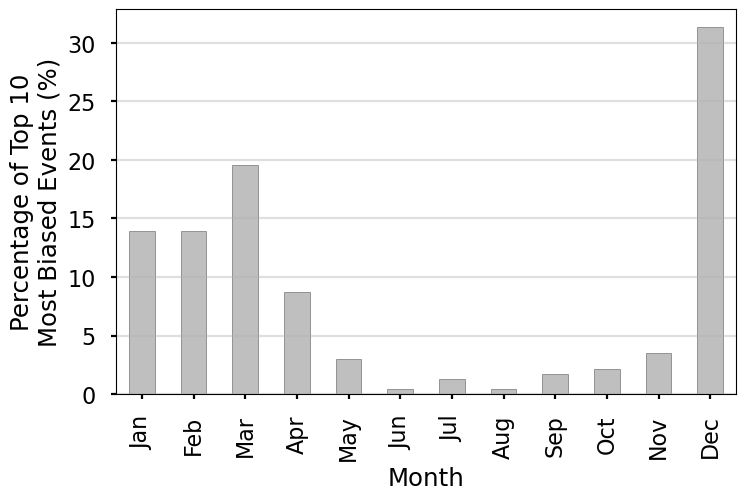

In [19]:
# plot a stacked barplot for each instrument showing counts per month
monthly_counts_df = (monthly_counts_ds / monthly_counts_ds.sum()).to_dataframe().reset_index()
# pivot to wide format: rows = month, columns = instrument
pivot_df = monthly_counts_df.pivot(
    index='month',
    columns='test_instrument',
    values='start_time'
).fillna(0)

months = np.arange(0, 12)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use('seaborn-v0_8-poster')
# plot pivot table as barplot with sums 
(pivot_df.sum(axis=1)*100).plot(kind='bar', stacked=True, ax=ax, color='grey',ec='k', label='Total', alpha=0.5)

ax.set_xticks(months)
ax.set_xticklabels(month_labels)

ax.set_xlabel('Month')
ax.set_ylabel('Percentage of Top 10\nMost Biased Events (%)')
# ax.set_title('Monthly Event Counts by Instrument at Gothic Site')
ax.grid(axis='y', alpha=0.4)

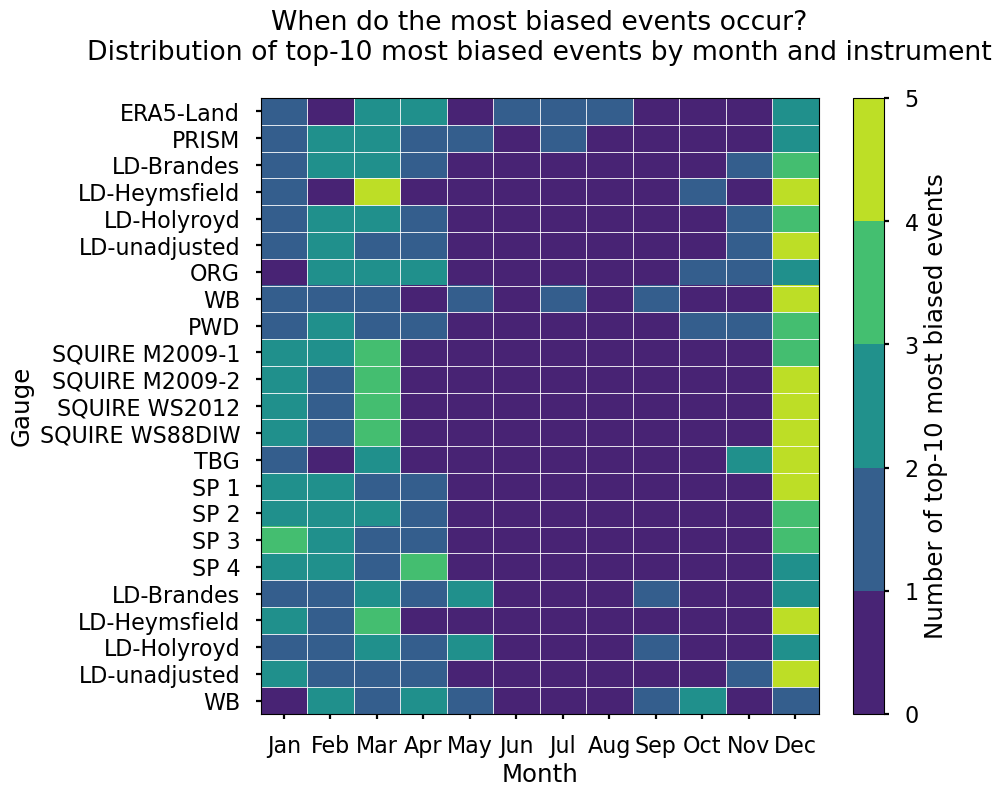

In [20]:
from utils.helper_funcs import INSTRUMENT_PLOT_DICT
from matplotlib.colors import ListedColormap, BoundaryNorm
# discrete cividis heatmap
base_cmap = plt.cm.viridis
bins = [0, 1,2,3,4,5]
colors = base_cmap(np.linspace(0.1, 0.9, len(bins) - 1))

cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N)

monthly_counts_df = (monthly_counts_ds ).to_dataframe().reset_index()
heatmap_df = monthly_counts_df.pivot(
    index='test_instrument',
    columns='month',
    values='start_time'
).fillna(0)

# Ensure months are ordered
heatmap_df = heatmap_df.reindex(columns=range(1, 13))
heatmap_df = heatmap_df.loc[
    heatmap_df.sum(axis=1).sort_values(ascending=False).index
].T

for idx in heatmap_df.columns:
    # rename the column
    heatmap_df = heatmap_df.rename(columns={idx: INSTRUMENT_PLOT_DICT[idx]['name']})
heatmap_df = heatmap_df.T

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    heatmap_df.values,
    aspect='auto',
    cmap=cmap,
    vmin=0
)

# Axis ticks and labels
ax.set_xticks(np.arange(12))
ax.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_xlabel('Month')
ax.set_ylabel('Gauge')
ax.set_title('When do the most biased events occur?\nDistribution of top-10 most biased events by month and instrument\n')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    'Number of top-10 most biased events',
    rotation=90
)
# draw grid lines between cells
ax.set_xticks(np.arange(-0.5, heatmap_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heatmap_df.shape[0], 1), minor=True)

ax.grid(which='minor', color='white', linestyle='-', linewidth=0.6)

# turn off minor tick labels
ax.tick_params(which='minor', bottom=False, left=False)

fig.savefig('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/for_manuscript/event_monthly_distribution_heatmap.png', dpi=300, bbox_inches='tight')